# Agent

## Tokenizer

In [1]:
from transformers import PreTrainedTokenizerFast

chat_template = """
{%- set default_system = 'Bạn là trợ lý AI hỗ trợ khách hàng. Hãy trả lời rõ ràng, chính xác và hữu ích.' -%}
{%- set ns = namespace(system=default_system) -%}
{%- if messages[0]['role'] == 'system' -%}{%- set ns.system = messages[0]['content'] -%}{%- endif -%}
{{- '<|im_start|>system\n' -}}
{{- ns.system }}
{%- if tools %}
Bạn có thể dùng các công cụ sau:
<tools>
{%- for tool in tools %}
{{- '\n' + (tool | tojson) }}
{%- endfor %}
</tools>
Khi cần gọi công cụ, trả về:
<tool_call>
{"name": <tên-hàm>, "arguments": <tham-số>}
</tool_call>
{%- endif %}
{{- '<|im_end|>\n' }}
{%- for message in messages %}
{%- if loop.first and message['role'] == 'system' %}
{%- continue %}
{%- endif %}
{%- if message['role'] == 'tool' %}
{%- if loop.first or messages[loop.index0-1]['role'] != 'tool' %}
{{- '<|im_start|>user\n' }}
{%- endif %}
{{- '<tool_response>\n' + message['content'] + '\n</tool_response>' }}
{%- if loop.last or messages[loop.index0+1]['role'] != 'tool' %}
{{- '<|im_end|>\n' }}
{%- endif %}
{%- elif message['role'] == 'assistant' %}
{{- '<|im_start|>assistant' }}
{%- if message.get('content') %}{{- '\n' + message['content'] }}{% endif %}
{%- for tc in message.get('tool_calls', []) %}
{%- set f = tc.get('function', tc) %}
{{- '\n<tool_call>\n{"name": "' + f['name'] + '", "arguments": ' + (f['arguments'] | tojson) + '}\n</tool_call>' }}
{%- endfor %}
{{- '<|im_end|>\n' }}
{%- else %}
{{- '<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>\n' }}
{%- endif %}
{%- endfor %}
{%- if add_generation_prompt %}{{- '<|im_start|>assistant\n' }}{% endif %}
""".strip()
# additional_special_tokens = ["<|im_start|>", "<|im_end|>"]

tokenizer = PreTrainedTokenizerFast(tokenizer_file="./SpikeGPT/20B_tokenizer.json", chat_template = chat_template)

c:\Users\pikke\miniconda3\envs\bt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
tools = [
    {
        "name": "check_inventory",
        "description": "Kiểm tra tồn kho",
        "parameters": {
            "properties": {
                "product_id": "ID sản phẩm"
            },
        }
    },
    {
        "name": "revenue_analysis",
        "description": "Thống kê doanh thu",
        "parameters": {
            "properties": {
                "start_date": "Ngày bắt đầu (YYYY-MM-DD)",
                "end_date":  "Ngày kết thúc (YYYY-MM-DD)"
            }
        }
    },
    {
        "name": "get_order",
        "description": "Kiểm tra đơn hàng",
        "parameters": {
            "properties": {
                "order_id": "ID đơn hàng"
            }
        }
    },
    {
        "name": "create_order",
        "description": "Tạo đơn hàng mới",
        "parameters": {
            "type": "object",
            "properties": {
                "product_id": "ID sản phẩm",
                "quantity":  "Số lượng",
                "address": "Địa chỉ giao hàng"
            }
        }
    },
    {
        "name": "update_order",
        "description": "Cập nhật đơn hàng",
        "parameters": {
            "properties": {
                "order_id":  "ID đơn hàng",
                "quantity": "Số lượng mới",
                "address": "Địa chỉ mới"
            },
        }
    },
    {
        "name": "delete_order",
        "description": "Hủy đơn hàng",
        "parameters": {
            "properties": {
                "order_id":"ID đơn hàng"
            }
        }
    }
]

messages = [
  {
    "role": "user",
    "content": "Kho còn bao nhiêu sản phẩm có ID là P100?"
  },
  {
    "role": "assistant",
    "content": "",
    "tool_calls": [
      {
        "name": "check_inventory",
        "arguments": {
          "product_id": "P100"
        }
      }
    ]
  }
]

print(tokenizer.decode(tokenizer.apply_chat_template(messages, tokenize=True, tools= tools)))
print(len(tokenizer.encode(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, tools= tools))))

<|im_start|>system
Bạn là trợ lý AI hỗ trợ khách hàng. Hãy trả lời rõ ràng, chính xác và hữu ích.Bạn có thể dùng các công cụ sau:
<tools>
{"name": "check_inventory", "description": "Kiểm tra tồn kho", "parameters": {"properties": {"product_id": "ID sản phẩm"}}}
{"name": "revenue_analysis", "description": "Thống kê doanh thu", "parameters": {"properties": {"start_date": "Ngày bắt đầu (YYYY-MM-DD)", "end_date": "Ngày kết thúc (YYYY-MM-DD)"}}}
{"name": "get_order", "description": "Kiểm tra đơn hàng", "parameters": {"properties": {"order_id": "ID đơn hàng"}}}
{"name": "create_order", "description": "Tạo đơn hàng mới", "parameters": {"type": "object", "properties": {"product_id": "ID sản phẩm", "quantity": "Số lượng", "address": "Địa chỉ giao hàng"}}}
{"name": "update_order", "description": "Cập nhật đơn hàng", "parameters": {"properties": {"order_id": "ID đơn hàng", "quantity": "Số lượng mới", "address": "Địa chỉ mới"}}}
{"name": "delete_order", "description": "Hủy đơn hàng", "parameters":

**Loading Data**

In [55]:
import json

with open('./data/agent_data1.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(data)

[{'id': 'sample_001', 'description': 'Kiểm tra tồn kho của một sản phẩm', 'tool_used': ['check_inventory'], 'messages': [{'role': 'user', 'content': 'Bạn kiểm tra giúp tôi xem mã sản phẩm SP-8845 trong kho còn hàng không nhé.'}, {'role': 'assistant', 'content': None, 'tool_calls': [{'name': 'check_inventory', 'arguments': {'product_id': 'SP-8845'}}]}]}, {'id': 'sample_002', 'description': 'Tạo đơn hàng mới (Ví dụ gốc của bạn)', 'tool_used': ['create_order'], 'messages': [{'role': 'user', 'content': 'Tôi muốn đặt 3 sản phẩm P200 giao đến 123 Lê Lợi, TP.HCM.'}, {'role': 'assistant', 'content': None, 'tool_calls': [{'name': 'create_order', 'arguments': {'product_id': 'P200', 'quantity': 3, 'address': '123 Lê Lợi, TP.HCM'}}]}]}, {'id': 'sample_003', 'description': 'Thống kê doanh thu trong một khoảng thời gian', 'tool_used': ['revenue_analysis'], 'messages': [{'role': 'user', 'content': 'Cho tôi xem báo cáo thống kê doanh thu từ ngày 1 tháng 4 năm 2026 đến ngày 15 tháng 4 năm 2026.'}, {'ro

In [56]:
import pandas as pd

ds = pd.read_json("./data/agent_data1.json")
ds

,id,description,tool_used,messages
0,sample_001,Kiểm tra tồn kho của một sản phẩm,[check_inventory],"[{'role': 'user', 'content': 'Bạn kiểm tra giú..."
1,sample_002,Tạo đơn hàng mới (Ví dụ gốc của bạn),[create_order],"[{'role': 'user', 'content': 'Tôi muốn đặt 3 s..."
2,sample_003,Thống kê doanh thu trong một khoảng thời gian,[revenue_analysis],"[{'role': 'user', 'content': 'Cho tôi xem báo ..."
3,sample_004,Tra cứu thông tin đơn hàng hiện tại,[get_order],"[{'role': 'user', 'content': 'Đơn hàng ORD-112..."
4,sample_005,Cập nhật đơn hàng (thay đổi cả số lượng và địa...,[update_order],"[{'role': 'user', 'content': 'Tôi muốn cập nhậ..."
...,...,...,...,...
512,sample_506,Tạo đơn hàng bánh trung thu cao cấp,[create_order],"[{'role': 'user', 'content': 'Đặt 10 hộp bánh ..."
513,sample_507,Tra cứu đơn hàng điện tử sỉ,[get_order],"[{'role': 'user', 'content': 'Xem trạng thái đ..."
514,sample_508,Cập nhật đơn hàng sỉ nước khoáng,[update_order],"[{'role': 'user', 'content': 'Đơn sỉ mã WATER-..."
515,sample_509,Hủy đơn hàng Lazada,[delete_order],"[{'role': 'user', 'content': 'Hủy đơn Lazada m..."


In [36]:
print(ds.iloc[1].to_json(force_ascii=False))

{"id":"sample_002","description":"Tạo đơn hàng mới","tool_used":["create_order"],"messages":[{"role":"user","content":"Tôi muốn đặt 3 sản phẩm P200 giao đến 123 Lê Lợi, TP.HCM."},{"role":"assistant","content":null,"tool_calls":[{"name":"create_order","arguments":{"product_id":"P200","quantity":3,"address":"123 Lê Lợi, TP.HCM"}}]},{"role":"tool","content":"{\"order_id\": \"ORD001\", \"status\": \"success\", \"message\": \"Đơn hàng đã được tạo thành công\"}"},{"role":"assistant","content":"Đơn hàng của bạn đã được tạo thành công! Mã đơn hàng là ORD001."}]}


**Check Data**

In [57]:
total = len(ds)
mistake = 0

for i, data in ds.iterrows():  # Unpack (index, row)
    tools_in_messages = []
    for msg in data["messages"]:
        if "tool_calls" in msg and msg["tool_calls"]:
            for tool_call in msg["tool_calls"]:
                try:
                    tools_in_messages.append(tool_call["name"])
                except:
                    print(f"Error in sample {i}")

    tool_used = data["tool_used"]

    is_match = set(tools_in_messages) == set(tool_used)
    if not is_match:
        print(f"Data {i} has error!")
        print("Tools in messages:", tools_in_messages) 
        print("Tool used:        ", tool_used)      
    
        mistake += 1

print("Total error data:", mistake)

Total error data: 0


In [49]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1001 non-null   object
 1   description  1001 non-null   object
 2   tool_used    1001 non-null   object
 3   messages     1001 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [11]:
ds.iloc[40]

id                                                           021
description            Cập nhật đơn hàng thất bại do sai mã đơn.
tool_used                                         [update_order]
messages       [{'role': 'user', 'content': 'Cập nhật cho tôi...
Name: 40, dtype: object

In [18]:
messages

[{'role': 'user', 'content': 'Kho còn bao nhiêu sản phẩm có ID là P100?'},
 {'role': 'assistant',
  'content': '',
  'tool_calls': [{'name': 'check_inventory',
    'arguments': {'product_id': 'P100'}}]},
 {'role': 'tool', 'content': '{"product_id": "P100", "stock": 25}'},
 {'role': 'assistant',
  'content': 'Sản phẩm P100 hiện còn 25 sản phẩm trong kho.'}]

In [58]:
def remove_long_text_sample(ds: pd.DataFrame, tokenizer) -> pd.DataFrame:
    rows = []

    def token_count(messages):
        return len(tokenizer.apply_chat_template(messages, tokenize=True, tools=tools)['input_ids'])

    for i, data in ds.iterrows():
        messages = data['messages']
        if token_count(messages) <= 800:
            rows.append(data.to_dict())

    return pd.DataFrame(rows, columns=ds.columns)

new_data = remove_long_text_sample(ds, tokenizer)

In [59]:
new_data

,id,description,tool_used,messages
0,sample_001,Kiểm tra tồn kho của một sản phẩm,[check_inventory],"[{'role': 'user', 'content': 'Bạn kiểm tra giú..."
1,sample_002,Tạo đơn hàng mới (Ví dụ gốc của bạn),[create_order],"[{'role': 'user', 'content': 'Tôi muốn đặt 3 s..."
2,sample_003,Thống kê doanh thu trong một khoảng thời gian,[revenue_analysis],"[{'role': 'user', 'content': 'Cho tôi xem báo ..."
3,sample_004,Tra cứu thông tin đơn hàng hiện tại,[get_order],"[{'role': 'user', 'content': 'Đơn hàng ORD-112..."
4,sample_005,Cập nhật đơn hàng (thay đổi cả số lượng và địa...,[update_order],"[{'role': 'user', 'content': 'Tôi muốn cập nhậ..."
...,...,...,...,...
512,sample_506,Tạo đơn hàng bánh trung thu cao cấp,[create_order],"[{'role': 'user', 'content': 'Đặt 10 hộp bánh ..."
513,sample_507,Tra cứu đơn hàng điện tử sỉ,[get_order],"[{'role': 'user', 'content': 'Xem trạng thái đ..."
514,sample_508,Cập nhật đơn hàng sỉ nước khoáng,[update_order],"[{'role': 'user', 'content': 'Đơn sỉ mã WATER-..."
515,sample_509,Hủy đơn hàng Lazada,[delete_order],"[{'role': 'user', 'content': 'Hủy đơn Lazada m..."


In [210]:
new_data.iloc[17]['messages']

[{'role': 'user', 'content': 'Ừ kiểm tra P701 đi.'},
 {'role': 'assistant',
  'content': None,
  'tool_calls': [{'name': 'check_inventory',
    'arguments': {'product_id': 'P701'}}]},
 {'role': 'tool', 'content': '{"product_id": "P701", "stock": 15}'},
 {'role': 'assistant',
  'content': 'P701 còn 15 cái trong kho. Bạn có muốn đặt không?'},
 {'role': 'user', 'content': 'Đặt 2 cái giao 77 Nguyễn Trãi, TP.HCM.'},
 {'role': 'assistant',
  'content': None,
  'tool_calls': [{'name': 'create_order',
    'arguments': {'product_id': 'P701',
     'quantity': 2,
     'address': '77 Nguyễn Trãi, TP.HCM'}}]},
 {'role': 'tool', 'content': '{"order_id": "ORD010", "status": "success"}'},
 {'role': 'assistant',
  'content': 'Đã đặt 2 sản phẩm P701 thành công! Mã đơn hàng là ORD010, giao đến 77 Nguyễn Trãi, TP.HCM.'}]

In [61]:
import json

skipped = 0

with open("tool_data1.jsonl", "w", encoding="utf-8") as f:
    for _, example in new_data.iterrows():  
        try:
            text = tokenizer.apply_chat_template(
                example['messages'],
                tokenize=False,
                tools=tools,
                add_generation_prompt=False 
            )

            if not text or not text.strip():
                skipped += 1
                continue

            json.dump({"text": text}, f, ensure_ascii=False)
            f.write("\n")

        except Exception as e:
            print(f"[WARNING] Skipping example {example.get('id', '?')}: {e}")
            skipped += 1

print(f"Done writing JSONL — skipped {skipped} examples.")

Done writing JSONL — skipped 0 examples.


# **Base**

## **Dataset**

### **VietGPT**

In [45]:
from datasets import load_dataset
dataset = load_dataset("vietgpt/wikipedia_vi", split= "train")

KeyboardInterrupt: 

**EDA**

In [ ]:
dataset

Dataset({
    features: ['id', 'revid', 'url', 'title', 'text'],
    num_rows: 1284930
})

In [12]:
dataset[1]

{'id': 4,
 'revid': '686003',
 'url': 'https://vi.wikipedia.org/wiki?curid=4',
 'title': 'Internet Society',
 'text': 'Internet Society hay ISOC là một tổ chức quốc tế hoạt động phi lợi nhuận, phi chính phủ và bao gồm các thành viên có trình độ chuyên ngành. Tổ chức này chú trọng đến: tiêu chuẩn, giáo dục và các vấn đề về chính sách. Với trên 145 tổ chức thành viên và 65.000 thành viên cá nhân, ISOC bao gồm những con người cụ thể trong cộng đồng Internet. Mọi chi tiết có thể tìm thấy tại website của ISOC.\nInternet Society nằm ở gần thủ đô Washington, DC, Hoa Kỳ và Geneva, Thụy Sĩ. Số hội viên của nó bao gồm hơn 145 tổ chức thành viên và hơn 65.000 cá nhân. Thành viên còn có thể tự lập một chi nhánh của tổ chức tùy theo vị trí hoặc sở thích. Hiện nay tổ chức có tới 90 chi nhánh trên toàn thế giới.\nNhiệm vụ và mục đích hoạt động.\nBảo đảm, cổ vũ cho sự phát triển, mở rộng và sử dụng Internet được thuận lợi nhất cho mọi người trên toàn thế giới.'}

In [ ]:
text_data = list(dataset['text'])

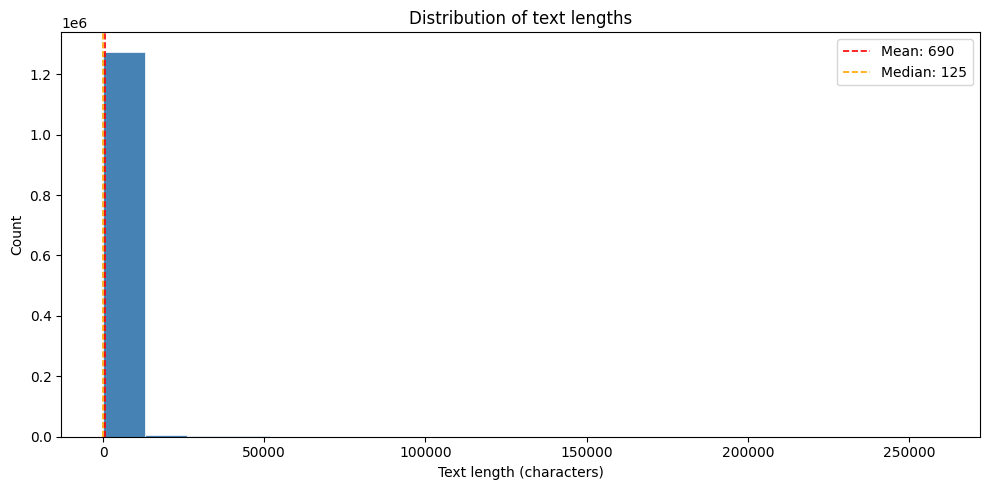

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

text_lengths = [len(text) for text in text_data]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(text_lengths, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {np.mean(text_lengths):.0f}')
ax.axvline(np.median(text_lengths), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {np.median(text_lengths):.0f}')

ax.set_xlabel('Text length (characters)')
ax.set_ylabel('Count')
ax.set_title('Distribution of text lengths')
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
print("Average text length: ",np.mean(text_lengths))
print("Text length = 0: ", np.sum(np.array(text_lengths) == 0))
print("Quantile of 5%: ", np.quantile(text_lengths,0.05))
print("Quantile of 25%: ", np.quantile(text_lengths, 0.25))
print("Quantile of 50%: ", np.quantile(text_lengths, 0.5))
print("Quantile of 75%: ", np.quantile(text_lengths, 0.75))
print("Quantile of 95&: ", np.quantile(text_lengths, 0.95))

Average text length:  690.406322523406
Text length = 0:  0
Quantile of 5%:  58.0
Quantile of 25%:  105.0
Quantile of 50%:  125.0
Quantile of 75%:  191.0
Quantile of 95&:  2811.0


In [47]:
print(len([text_length for text_length in text_lengths if text_length > 2811]))

64240


**Data Cleaning**

**Save in jsonl**

In [52]:
import json

with open("./data/wikipedia_vi.jsonl", "w", encoding="utf-8") as f:
    for example in dataset:
        # The dataset has a "text" column
        text = example.get("text", "").strip()
        if text:
            json.dump({"text": text}, f, ensure_ascii=False)
            f.write("\n")

print("Done writing JSONL")

NameError: name 'dataset' is not defined

In [13]:
!pip install ftfy==6.1.* lm-dataformat==0.0.20


   ---------------- ----------------------- 2/5 [jsonlines]
   ---------------------------------------- 5/5 [lm-dataformat]



In [62]:
!python "json2binidx_tool/tools/preprocess_data.py" --input "tool_data1.jsonl" --output-prefix "json2binidx_tool/data/tool_data" --vocab "json2binidx_tool/20B_tokenizer.json" --dataset-impl mmap --tokenizer-type HFTokenizer --append-eod


#######################################################################################################################

This tokenizer is not used in any RWKV models yet. I plan to use it for the future multilang RWKV models.

Benefits:

* Good support of most languages, from European to CJK to Arabic and Hindi and more.

* Clean vocab. Good for code too. Vocab size = 65525 (use 0 for <|endoftext|>).

* Good at numbers: the numerical tokens are '0'~'9', '10'~'99', ' 0'~' 9', ' 10'~' 99'.

* Very easy tokenization:

** The input text must be in UTF-8.

** Greedy encoding: always pick the longest (in bytes) token (with the highest id) that matches your UTF-8 bytes.

* The tokenization result is surprisingly good, because the vocab respects word boundaries and UTF-8 boundaries.

For 10x faster speed:
mypyc rwkv_tokenizer.py
python3 -c "import rwkv_tokenizer"

#######################################################################################################################

> buildi


0it [00:00, ?it/s]
Processed 100 documents (499.95 docs/s, 0.66 MB/s).: : 0it [00:00, ?it/s]
Processed 100 documents (499.95 docs/s, 0.66 MB/s).: : 100it [00:00, 515.96it/s]
Processed 200 documents (527.15 docs/s, 0.70 MB/s).: : 100it [00:00, 515.96it/s]
Processed 200 documents (527.15 docs/s, 0.70 MB/s).: : 200it [00:00, 539.60it/s]
Processed 300 documents (595.00 docs/s, 0.79 MB/s).: : 200it [00:00, 539.60it/s]
Processed 300 documents (595.00 docs/s, 0.79 MB/s).: : 300it [00:00, 634.16it/s]
Processed 400 documents (611.26 docs/s, 0.81 MB/s).: : 300it [00:00, 634.16it/s]
Processed 400 documents (611.26 docs/s, 0.81 MB/s).: : 400it [00:00, 646.32it/s]
Processed 500 documents (571.21 docs/s, 0.75 MB/s).: : 400it [00:00, 646.32it/s]
Processed 500 documents (571.21 docs/s, 0.75 MB/s).: : 500it [00:00, 559.88it/s]
Processed 500 documents (571.21 docs/s, 0.75 MB/s).: : 500it [00:00, 527.99it/s]


### 